In [17]:
import pandas as pd
df = pd.read_csv("A_Z Handwritten Data.csv")

In [18]:
df.shape

(372450, 785)

In [19]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df.columns[:5]

Index(['0', '0.1', '0.2', '0.3', '0.4'], dtype='object')

In [21]:
import pandas as pd
df = pd.read_csv("A_Z Handwritten Data.csv", header=None)

In [22]:
df.shape

(372451, 785)

In [23]:
df.head(3)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df[0].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25])

In [25]:
df[0].value_counts().sort_index()

0
0     13870
1      8668
2     23409
3     10134
4     11440
5      1163
6      5762
7      7218
8      1120
9      8493
10     5603
11    11586
12    12336
13    19010
14    57825
15    19341
16     5812
17    11566
18    48419
19    22495
20    29008
21     4182
22    10784
23     6272
24    10859
25     6076
Name: count, dtype: int64

In [26]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [27]:
X.shape

(372451, 784)

In [28]:
y.shape

(372451,)

In [29]:
X = X / 255.0

In [30]:
X.min(), X.max()

(1      0.0
 2      0.0
 3      0.0
 4      0.0
 5      0.0
       ... 
 780    0.0
 781    0.0
 782    0.0
 783    0.0
 784    0.0
 Length: 784, dtype: float64,
 1      0.000000
 2      0.000000
 3      0.000000
 4      0.000000
 5      0.000000
          ...   
 780    0.760784
 781    0.403922
 782    0.776471
 783    0.321569
 784    0.015686
 Length: 784, dtype: float64)

In [31]:
X = X.values.reshape(-1, 28, 28, 1)

In [32]:
X.shape

(372451, 28, 28, 1)

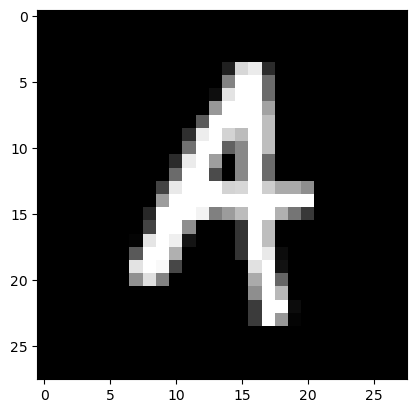

In [33]:
import matplotlib.pyplot as plt
plt.imshow(X[0], cmap='gray')
plt.show()

In [34]:
y[0]

np.int64(0)

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("A_Z Handwritten Data.csv", header=None)
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
X = X / 255.0
X = X.values.reshape(-1, 28, 28, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2,random_state=42)

In [37]:
X_train.shape

(297960, 28, 28, 1)

In [38]:
X_test.shape

(74491, 28, 28, 1)

In [39]:
y_train.shape

(297960,)

In [40]:
y_test.shape

(74491,)

In [41]:
y_train.min(), y_train.max()

(0, 25)

In [42]:
y_train.min(), y_train.max()

(0, 25)

In [43]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [44]:
model = Sequential([
    Conv2D(32,(3,3), activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(26, activation='softmax')
])

c:\Users\sarth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [47]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 139s 32ms/step - accuracy: 0.9170 - loss: 0.2903 - val_accuracy: 0.9774 - val_loss: 0.0778
Epoch 2/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 118s 28ms/step - accuracy: 0.9655 - loss: 0.1238 - val_accuracy: 0.9844 - val_loss: 0.0561
Epoch 3/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 88s 15ms/step - accuracy: 0.9732 - loss: 0.0961 - val_accuracy: 0.9857 - val_loss: 0.0513
Epoch 4/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 66s 16ms/step - accuracy: 0.9776 - loss: 0.0791 - val_accuracy: 0.9875 - val_loss: 0.0449
Epoch 5/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 61s 15ms/step - accuracy: 0.9803 - loss: 0.0690 - val_accuracy: 0.9893 - val_loss: 0.0414
Epoch 6/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 66s 16ms/step - accuracy: 0.9820 - loss: 0.0622 - val_accuracy: 0.9891 - val_loss: 0.0427
Epoch 7/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step - accuracy: 0.9834 - loss: 0.0553 - val_accuracy: 0.9900 - val_loss: 0.0407
Epoch 8/10
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 66s 16ms/step - accuracy: 0.9847

In [48]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9922 - loss: 0.0321


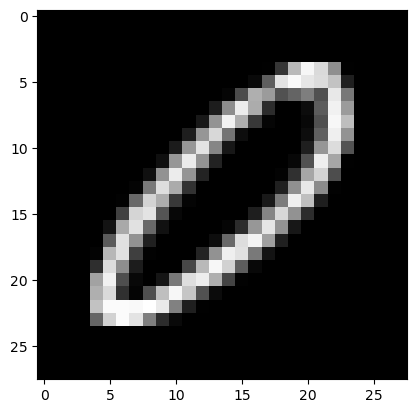

In [49]:
import random 
idx = random.randint(0, len(X_test) - 1)

plt.imshow(X_test[idx],cmap='gray')
plt.show()

In [50]:
prediction = model.predict(X_test[idx:idx+1])
predicted_label = prediction.argmax()
print("Predicted label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
Predicted label: 14


In [51]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [52]:
predicted_letter = letters[predicted_label]
print("Predicted letter:", predicted_letter)

Predicted letter: O


In [53]:
actual_label = int(y_test.iloc[idx])
actual_letter = letters[actual_label]

print("Actual letter:", actual_letter)

Actual letter: O


In [54]:
if predicted_letter == actual_letter:
    print("Correct prediction!")
else:
    print("Wrong prediction!")

Correct prediction!


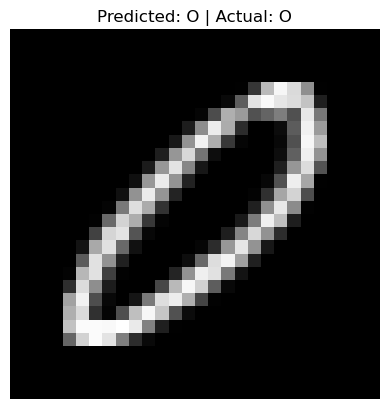

In [55]:
plt.imshow(X_test[idx], cmap='gray')
plt.title(f"Predicted: {predicted_letter} | Actual: {actual_letter}")
plt.axis('off')
plt.show()

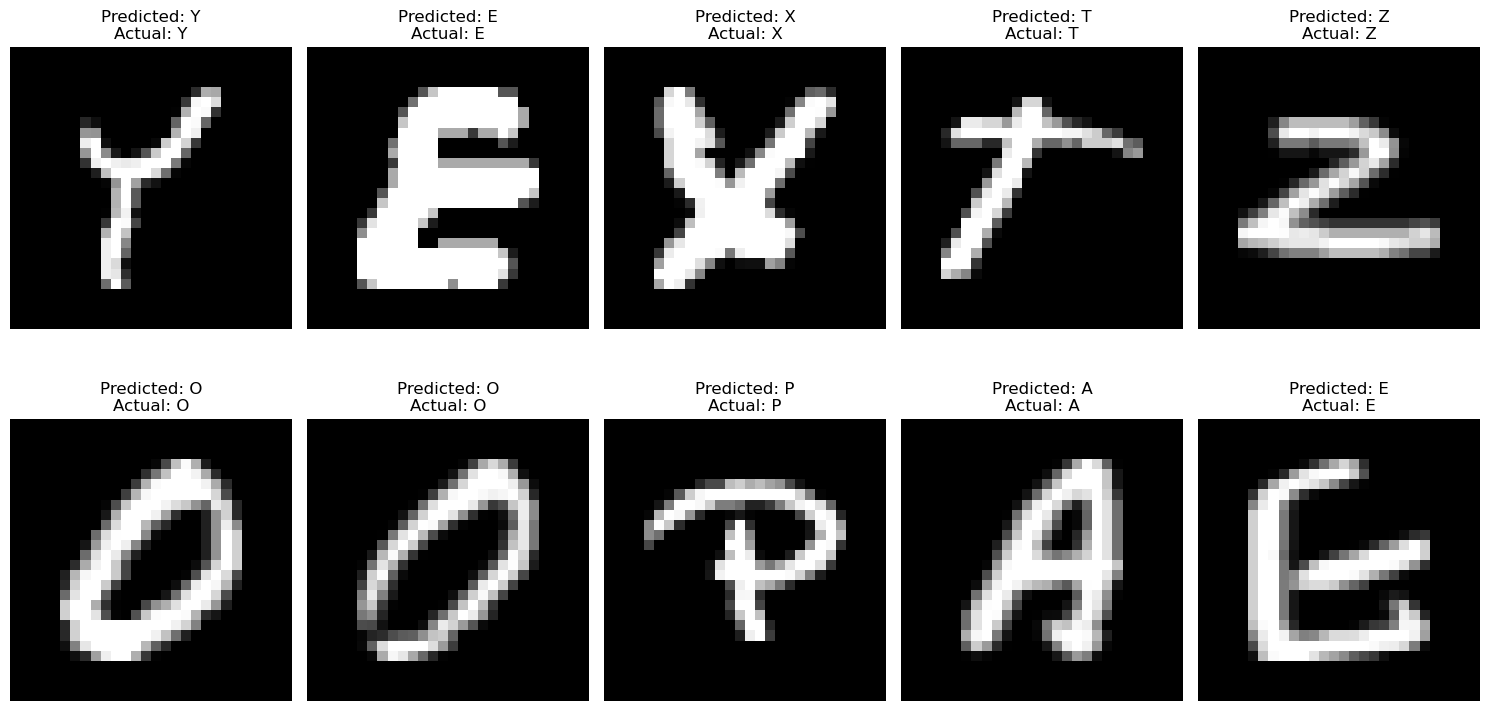

In [56]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i in range(10):
    idx = random.randint(0, len(X_test) - 1)

    prediction = model.predict(X_test[idx:idx+1], verbose=0)
    predicted_label = prediction.argmax()

    actual_label = int(y_test.iloc[idx])

    predicted_letter = letters[predicted_label]
    actual_letter = letters[actual_label]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Predicted: {predicted_letter}\nActual: {actual_letter}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [57]:
y_pred = model.predict(X_test, verbose=1)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step


In [58]:
y_pred_labels = y_pred.argmax(axis=1)

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_labels)

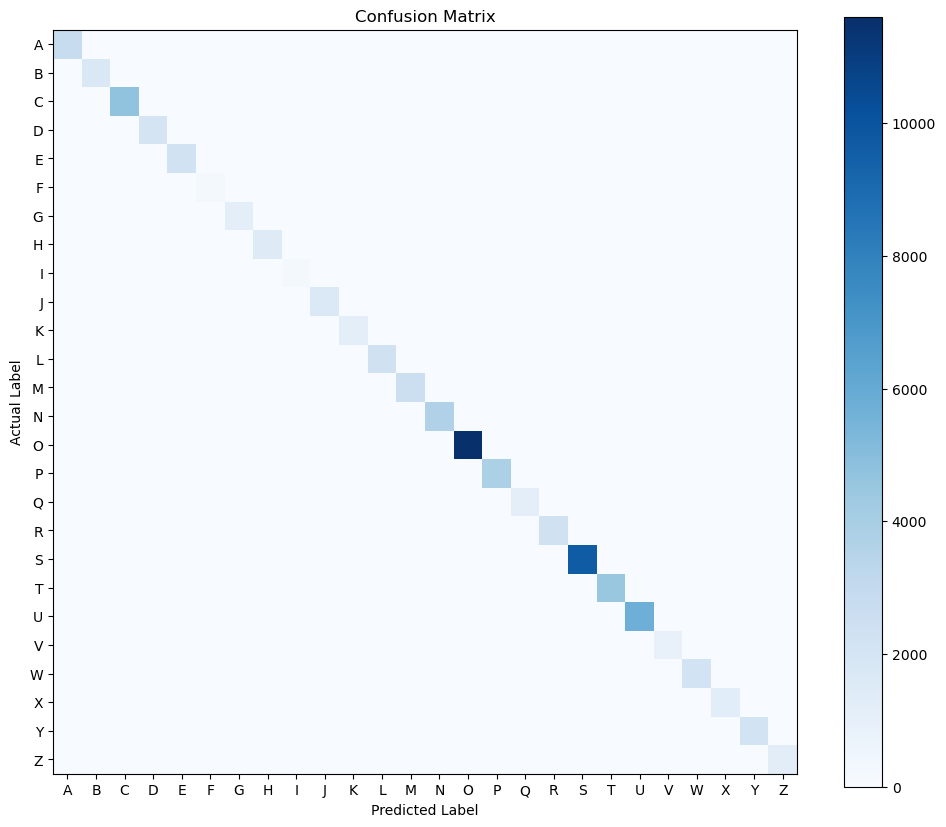

In [60]:
plt.figure(figsize=(12, 10))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.xticks(range(26), letters)
plt.yticks(range(26), letters)

plt.show()

In [61]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_labels,
    target_names=list(letters)
))

              precision    recall  f1-score   support

           A       1.00      0.99      0.99      2806
           B       0.99      0.99      0.99      1673
           C       0.99      0.99      0.99      4742
           D       0.97      0.98      0.97      2044
           E       1.00      0.99      0.99      2214
           F       1.00      0.97      0.98       232
           G       0.99      0.97      0.98      1183
           H       0.99      0.98      0.99      1456
           I       0.99      0.98      0.99       242
           J       0.98      0.97      0.98      1655
           K       0.98      0.99      0.98      1113
           L       0.99      0.99      0.99      2306
           M       0.99      1.00      0.99      2502
           N       0.99      0.99      0.99      3700
           O       1.00      0.99      0.99     11675
           P       1.00      0.99      1.00      3840
           Q       0.99      0.99      0.99      1184
           R       0.99    

In [62]:
model.save("alphabet_cnn.keras")

In [63]:
from PIL import Image

img = Image.open("my_letter.png")

print(img.size)

(1584, 396)


In [64]:
img = img.convert("L")

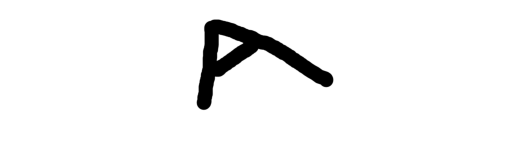

In [65]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [66]:
img = img.resize((28, 28))

In [67]:
print(img.size)

(28, 28)


In [68]:
import numpy as np

img_array = np.array(img)

In [69]:
print(img_array.shape)

(28, 28)


In [70]:
img_array = img_array / 255.0

In [71]:
print(img_array.min(), img_array.max())

0.0 1.0


In [72]:
img_array = img_array.reshape(1, 28, 28, 1)

In [73]:
print(img_array.shape)

(1, 28, 28, 1)


In [74]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


In [75]:
predicted_label = prediction.argmax()

In [76]:
predicted_letter = letters[predicted_label]

print("Predicted letter:", predicted_letter)

Predicted letter: O


In [77]:
prediction = model.predict(img_array)

predicted_label = prediction.argmax()

predicted_letter = letters[predicted_label]

print("Predicted letter:", predicted_letter)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted letter: O


In [78]:
print(prediction[0].max())

0.9117011


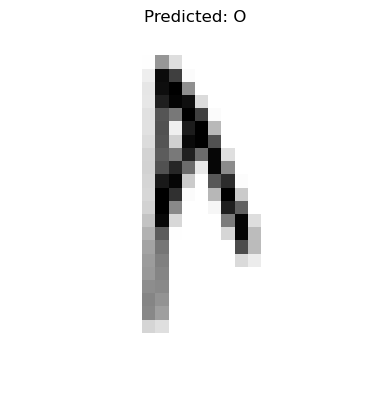

In [79]:
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_letter}")
plt.axis('off')
plt.show()

In [80]:
img_array = 1 - img_array

prediction = model.predict(img_array)

predicted_label = prediction.argmax()

predicted_letter = letters[predicted_label]

print("Predicted letter:", predicted_letter)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
Predicted letter: M


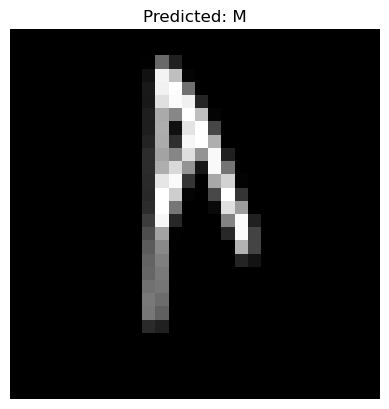

In [81]:
plt.imshow(img_array.reshape(28, 28), cmap="gray")
plt.title(f"Predicted: {predicted_letter}")
plt.axis("off")
plt.show()

In [82]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("my_letter.png").convert("L")

print(img.size)

(1584, 396)


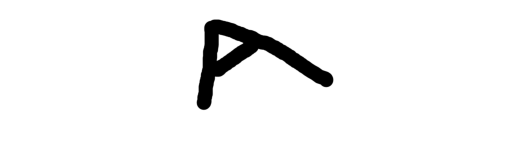

In [83]:
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [84]:
img_array_original = np.array(img)

coords = np.where(img_array_original < 128)

x_min, x_max = coords[1].min(), coords[1].max()
y_min, y_max = coords[0].min(), coords[0].max()

cropped = img.crop((x_min, y_min, x_max + 1, y_max + 1))

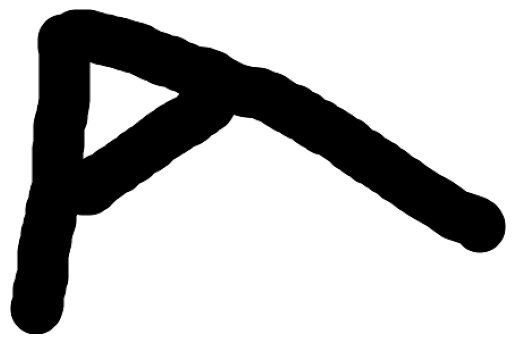

(437, 286)


In [85]:
plt.imshow(cropped, cmap="gray")
plt.axis("off")
plt.show()

print(cropped.size)

In [86]:
from PIL import Image

size = max(cropped.size)

square = Image.new("L", (size, size), 255)

x = (size - cropped.width) // 2
y = (size - cropped.height) // 2

square.paste(cropped, (x, y))

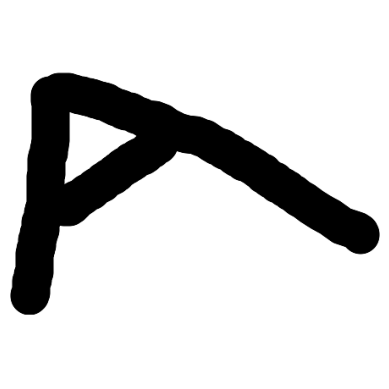

(437, 437)


In [87]:
plt.imshow(square, cmap="gray")
plt.axis("off")
plt.show()

print(square.size)

In [88]:
img_28 = square.resize((28, 28))

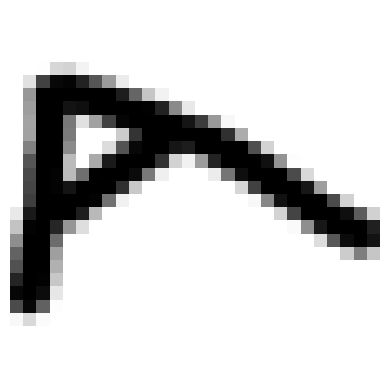

(28, 28)


In [89]:
plt.imshow(img_28, cmap="gray")
plt.axis("off")
plt.show()

print(img_28.size)

In [90]:
img_array = np.array(img_28)

In [91]:
print(img_array.shape)
print(img_array.min(), img_array.max())

(28, 28)
0 255


In [92]:
img_array = 255 - img_array

In [93]:
img_array = img_array / 255.0

In [94]:
print(img_array.min(), img_array.max())

0.0 1.0


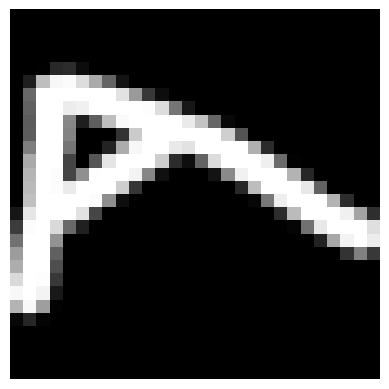

In [95]:
plt.imshow(img_array, cmap="gray")
plt.axis("off")
plt.show()

In [96]:
img_input = img_array.reshape(1, 28, 28, 1)

print(img_input.shape)

(1, 28, 28, 1)


In [97]:
prediction = model.predict(img_input, verbose=0)

predicted_label = prediction.argmax()

predicted_letter = letters[predicted_label]

print("Predicted letter:", predicted_letter)
print("Confidence:", prediction[0].max())

Predicted letter: D
Confidence: 0.5291847


In [99]:
top5 = prediction[0].argsort()[-5:][::-1]

for label in top5:
    print(letters[label], prediction[0][label])

D 0.5291847
M 0.31812894
T 0.09438844
N 0.044155434
P 0.012970053


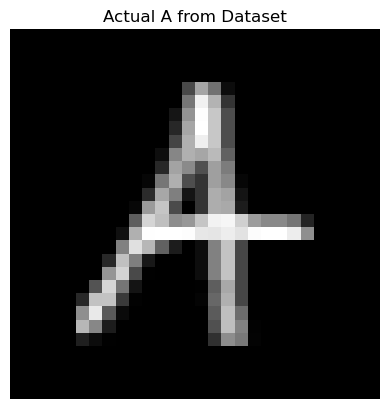

In [100]:
idx = np.where(y_test == 0)[0][0]

plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
plt.title("Actual A from Dataset")
plt.axis("off")
plt.show()

In [101]:
img = Image.open("my_letter2.png").convert("L")

print(img.size)

(1584, 396)


In [102]:
img_array_original = np.array(img)

coords = np.where(img_array_original < 128)

x_min, x_max = coords[1].min(), coords[1].max()
y_min, y_max = coords[0].min(), coords[0].max()

cropped = img.crop((x_min, y_min, x_max + 1, y_max + 1))

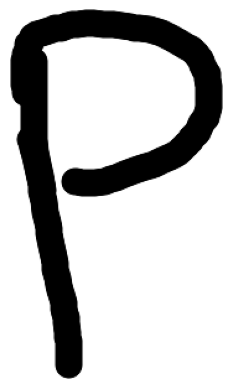

(172, 299)


In [103]:
plt.imshow(cropped, cmap="gray")
plt.axis("off")
plt.show()

print(cropped.size)

In [104]:
size = max(cropped.size)

square = Image.new("L", (size, size), 255)

x = (size - cropped.width) // 2
y = (size - cropped.height) // 2

square.paste(cropped, (x, y))

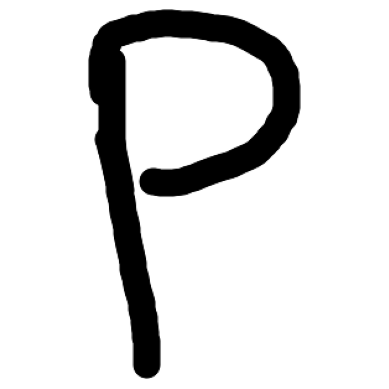

(299, 299)


In [105]:
plt.imshow(square, cmap="gray")
plt.axis("off")
plt.show()

print(square.size)

In [106]:
img_28 = square.resize((28, 28))

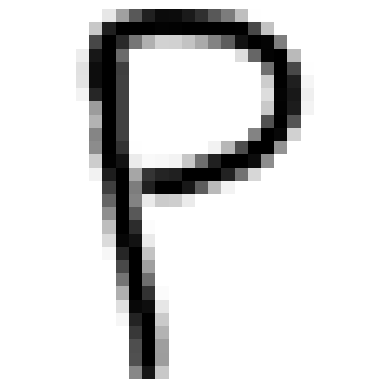

(28, 28)


In [107]:
plt.imshow(img_28, cmap="gray")
plt.axis("off")
plt.show()

print(img_28.size)

In [108]:
img_array = np.array(img_28)

print(img_array.shape)
print(img_array.min(), img_array.max())

(28, 28)
0 255


In [109]:
img_array = 255 - img_array

In [110]:
print(img_array.min(), img_array.max())

0 255


In [111]:
img_array = img_array / 255.0

In [112]:
print(img_array.min(), img_array.max())

0.0 1.0


In [113]:
img_input = img_array.reshape(1, 28, 28, 1)

print(img_input.shape)

(1, 28, 28, 1)


In [114]:
prediction = model.predict(img_input, verbose=0)

predicted_label = prediction.argmax()
predicted_letter = letters[predicted_label]

print("Predicted letter:", predicted_letter)
print("Confidence:", prediction[0].max())

Predicted letter: P
Confidence: 0.99721366
